# Amazon India E-Commerce Sales & Operations Analytics
### Exploratory Data Analysis, Statistical Testing & Visual Intelligence
**Author:** Data Analyst Portfolio Project  
**Dataset:** Kaggle (`thedevastator/unlock-profits-with-e-commerce-sales-data`)  
**Core Stack:** Python • Pandas • NumPy • Matplotlib • Seaborn • SciPy  
**Target Power BI Companion:** Star Schema (`FactOrderLine`, `DimProduct`, `DimGeography`, `DimStatus`, `DimDate`)

---

### Project Objectives & Business Questions
1. **Sales & Revenue Dynamics:** What is the daily and monthly sales run rate? What is the true Net Realized Revenue vs Gross Merchandise Value (GMV)?
2. **Data Grain & Multi-Item Orders:** How does transaction line-item grain differ from distinct order volume?
3. **Product & Merchandising Intelligence:** Which categories drive the bulk of revenue? Does the catalog follow a Pareto (80/20) rule? How does demand distribute across sizes?
4. **Logistics & Fulfillment Channels:** How does Amazon FBA compare to Merchant Easy Ship in terms of cancellation rates and fulfillment reliability?
5. **Geographic Demand:** Which states and metro clusters dominate purchasing volume?
6. **B2B vs B2C Behavior:** What are the ticket size (AOV) and order volume differences between retail shoppers and enterprise B2B buyers?


## 1. Environment Setup & Visual Configuration
Importing required scientific and visualization libraries with executive-grade plotting themes.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# Suppress minor warnings for clean report output
warnings.filterwarnings('ignore')

# Set global visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI', 'DejaVu Sans', 'Arial'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'semibold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 15

# Custom corporate color palette
AMAZON_NAVY = '#131921'
AMAZON_AMBER = '#FF9900'
AMAZON_BLUE = '#146EB4'
SLATE_GRAY = '#4A5568'
SUCCESS_GREEN = '#2E7D32'
DANGER_RED = '#C62828'
NEUTRAL_LIGHT = '#F8F9FA'

print("Libraries imported successfully. Matplotlib & Seaborn visual theme configured.")


Libraries imported successfully. Matplotlib & Seaborn visual theme configured.


## 2. Data Ingestion & Grain Verification
Loading the pre-processed cleaned dataset and establishing ground-truth control totals.


In [2]:
# Load cleaned master dataset
data_path = os.path.join('..', 'data', 'processed', 'cleaned_amazon_sales.csv')
if not os.path.exists(data_path):
    data_path = os.path.join('data', 'processed', 'cleaned_amazon_sales.csv')

df = pd.read_csv(data_path, low_memory=False)
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date Range:         {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print("\nFirst 3 Records:")
display(df[['order_id', 'date', 'status_group', 'fulfilment', 'category', 'size', 'qty', 'amount', 'net_revenue', 'ship_state']].head(3))


Dataset Dimensions: 128,975 rows x 36 columns
Date Range:         2022-03-31 to 2022-06-29

First 3 Records:


,order_id,date,status_group,fulfilment,category,size,qty,amount,net_revenue,ship_state
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Set,S,0,647.62,0.0,Maharashtra
1,171-9198151-1101146,2022-04-30,Delivered/Shipped,Merchant,Kurta,3XL,1,406.00,406.0,Karnataka
2,404-0687676-7273146,2022-04-30,Delivered/Shipped,Amazon,Kurta,XL,1,329.00,329.0,Maharashtra


In [3]:
# Data Grain & Distinct Count Verification
total_rows = len(df)
distinct_orders = df['order_id'].nunique()
distinct_skus = df['sku'].nunique()
multi_line_ratio = total_rows / distinct_orders

print("=" * 70)
print("DATA GRAIN VERIFICATION SUMMARY")
print("=" * 70)
print(f"Total Rows (Line-Item Grain):    {total_rows:,}")
print(f"Distinct Order IDs:              {distinct_orders:,}")
print(f"Distinct Product SKUs:           {distinct_skus:,}")
print(f"Average Line-Items per Order:    {multi_line_ratio:.3f}")
print("-> RULE: 1 row = 1 SKU line item in an order.")
print("-> Order metrics must use nunique() / DISTINCTCOUNT to prevent double-counting.")
print("=" * 70)


DATA GRAIN VERIFICATION SUMMARY
Total Rows (Line-Item Grain):    128,975
Distinct Order IDs:              120,378
Distinct Product SKUs:           7,195
Average Line-Items per Order:    1.071
-> RULE: 1 row = 1 SKU line item in an order.
-> Order metrics must use nunique() / DISTINCTCOUNT to prevent double-counting.


## 3. Executive KPI Summary
Calculating core top-line metrics: GMV, Net Revenue, Fulfilled Volume, Cancellation Rate, and Average Order Value (AOV).


In [4]:
# Executive KPI Calculations
gross_revenue = df['amount'].sum()
net_revenue = df['net_revenue'].sum()
total_units = df['qty'].sum()

fulfilled_mask = ~df['is_cancelled'] & ~df['is_returned']
fulfilled_orders = df[fulfilled_mask]['order_id'].nunique()
cancelled_orders = df[df['is_cancelled']]['order_id'].nunique()
returned_orders = df[df['is_returned']]['order_id'].nunique()

cancellation_rate = (cancelled_orders / distinct_orders) * 100
return_rate = (returned_orders / distinct_orders) * 100
aov = net_revenue / fulfilled_orders if fulfilled_orders else 0
units_per_order = total_units / fulfilled_orders if fulfilled_orders else 0

b2b_orders = df[df['b2b']]['order_id'].nunique()
b2b_revenue = df[df['b2b']]['net_revenue'].sum()

# Display KPI Scorecard
kpi_df = pd.DataFrame({
    'Metric': [
        'Gross Merchandise Value (GMV)',
        'Net Realized Revenue',
        'Total Orders Processed',
        'Fulfilled Orders',
        'Average Order Value (AOV)',
        'Total Garment Units Sold',
        'Order Cancellation Rate',
        'Return to Seller (RTS) Rate',
        'B2B Revenue Contribution'
    ],
    'Value': [
        f"INR {gross_revenue:,.2f}",
        f"INR {net_revenue:,.2f}",
        f"{distinct_orders:,}",
        f"{fulfilled_orders:,} ({fulfilled_orders/distinct_orders:.1%})",
        f"INR {aov:,.2f}",
        f"{total_units:,} units",
        f"{cancellation_rate:.2f}%",
        f"{return_rate:.2f}%",
        f"INR {b2b_revenue:,.2f} ({b2b_revenue/net_revenue:.2%})"
    ]
})

display(kpi_df.style.set_properties(**{'text-align': 'left', 'font-family': 'Segoe UI'}))


,Metric,Value
0,Gross Merchandise Value (GMV),"INR 78,681,022.35"
1,Net Realized Revenue,"INR 70,374,984.05"
2,Total Orders Processed,"120,378"
3,Fulfilled Orders,"101,201 (84.1%)"
4,Average Order Value (AOV),INR 695.40
5,Total Garment Units Sold,"116,649 units"
6,Order Cancellation Rate,14.35%
7,Return to Seller (RTS) Rate,1.65%
8,B2B Revenue Contribution,"INR 553,411.00 (0.79%)"


## 4. Sales & Revenue Time-Series Dynamics
Analyzing revenue run-rate, daily order volumes, 7-day rolling averages, and day-of-week seasonality.


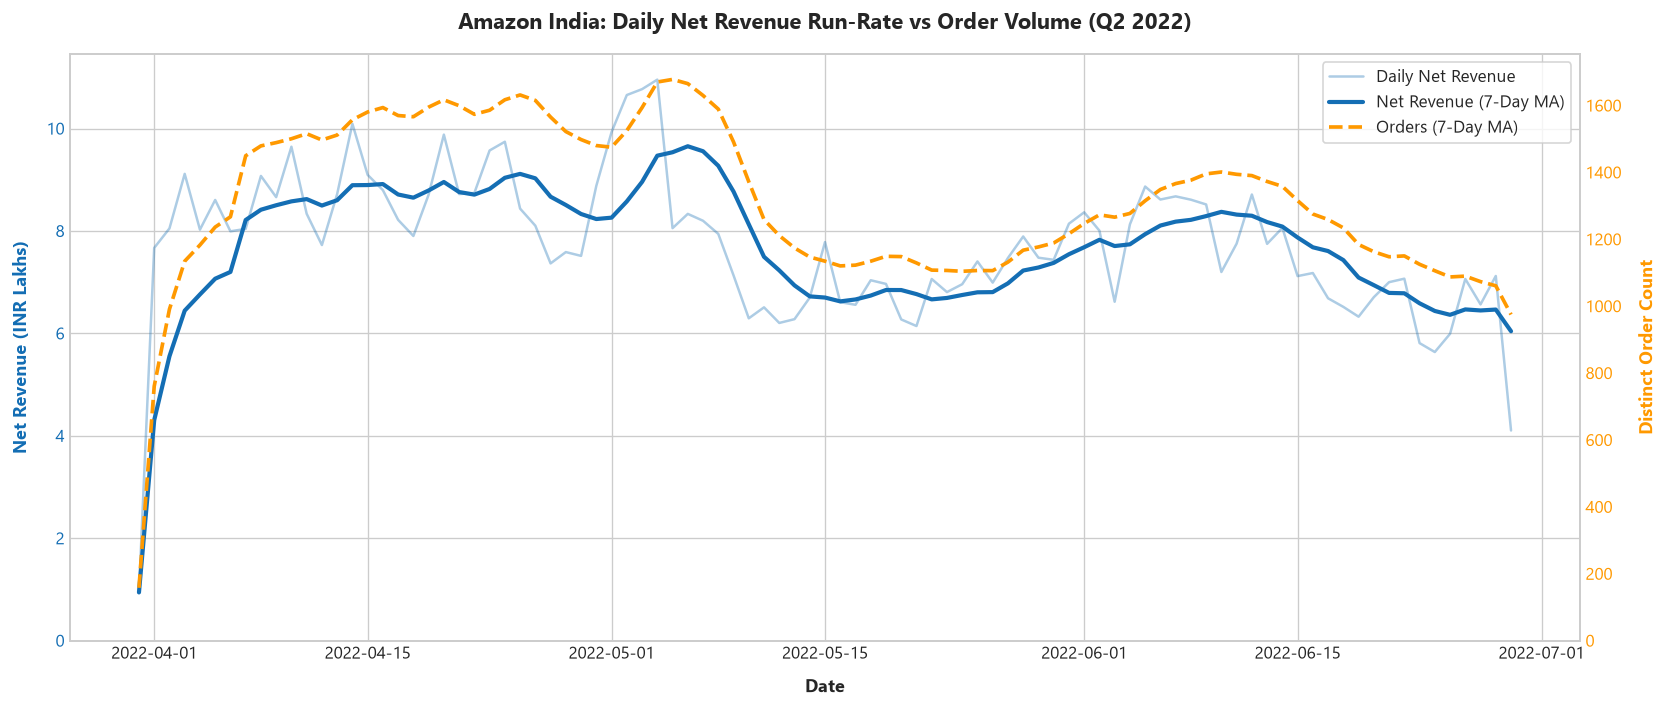

In [5]:
# Daily Aggregate Analysis
daily_sales = df.groupby('date').agg(
    gross_revenue=('amount', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    order_count=('order_id', 'nunique'),
    units=('qty', 'sum')
).reset_index()

# 7-day Moving Average for smoothing volatility
daily_sales['rev_7d_ma'] = daily_sales['net_revenue'].rolling(window=7, min_periods=1).mean()
daily_sales['orders_7d_ma'] = daily_sales['order_count'].rolling(window=7, min_periods=1).mean()

# Dual-Axis Time-Series Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

color_rev = AMAZON_BLUE
color_orders = AMAZON_AMBER

ax1.plot(daily_sales['date'], daily_sales['net_revenue'] / 1e5, color=color_rev, alpha=0.35, label='Daily Net Revenue')
ax1.plot(daily_sales['date'], daily_sales['rev_7d_ma'] / 1e5, color=color_rev, linewidth=2.5, label='Net Revenue (7-Day MA)')
ax1.set_xlabel('Date', fontweight='bold', labelpad=10)
ax1.set_ylabel('Net Revenue (INR Lakhs)', color=color_rev, fontweight='bold', labelpad=10)
ax1.tick_params(axis='y', labelcolor=color_rev)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(daily_sales['date'], daily_sales['orders_7d_ma'], color=color_orders, linewidth=2.2, linestyle='--', label='Orders (7-Day MA)')
ax2.set_ylabel('Distinct Order Count', color=color_orders, fontweight='bold', labelpad=10)
ax2.tick_params(axis='y', labelcolor=color_orders)
ax2.grid(False)
ax2.set_ylim(bottom=0)

plt.title('Amazon India: Daily Net Revenue Run-Rate vs Order Volume (Q2 2022)', pad=15)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


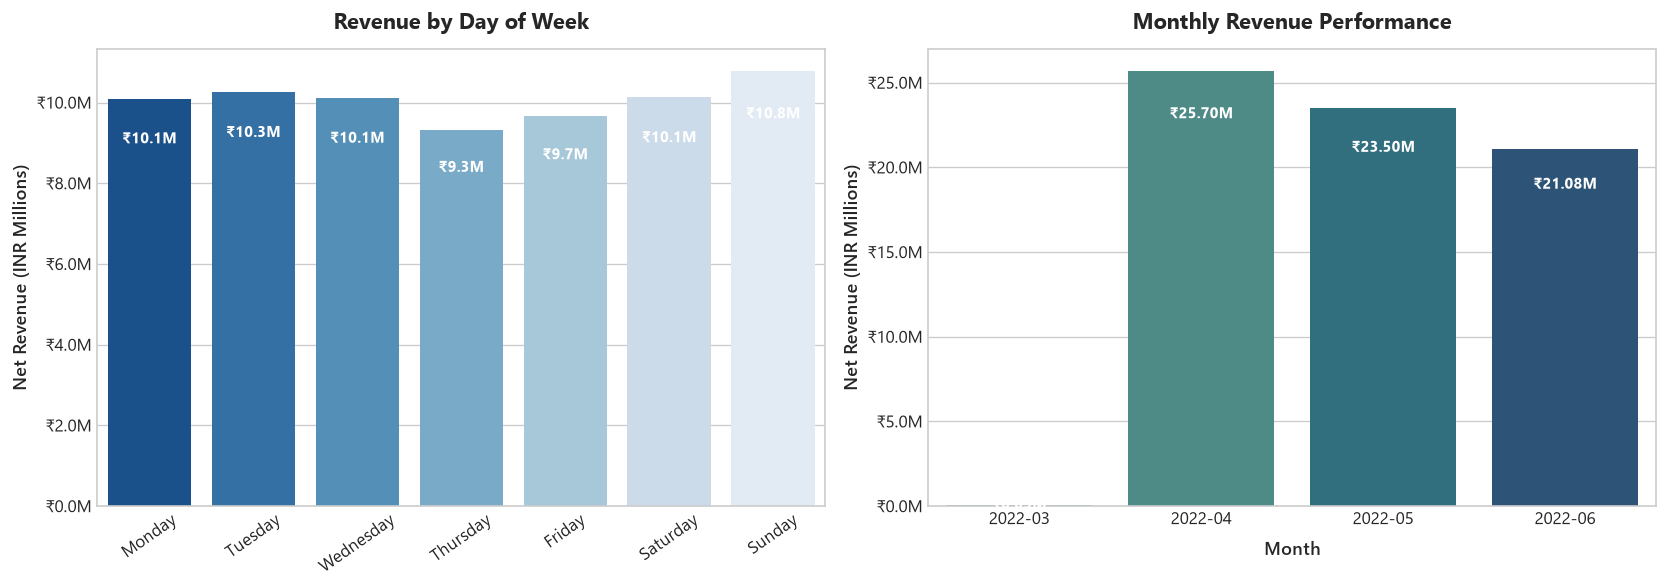

In [6]:
# Day of Week & Monthly Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Day of Week Analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary = df.groupby('day_of_week').agg(
    net_revenue=('net_revenue', 'sum'),
    orders=('order_id', 'nunique')
).reindex(day_order).reset_index()

sns.barplot(
    data=dow_summary,
    x='day_of_week',
    y='net_revenue',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Revenue by Day of Week', pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Net Revenue (INR Millions)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₹{x*1e-6:.1f}M'))
axes[0].tick_params(axis='x', rotation=35)

# Add data labels
for p in axes[0].patches:
    val = p.get_height()
    axes[0].annotate(f'₹{val*1e-6:.1f}M', (p.get_x() + p.get_width() / 2., val * 0.90),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# 2. Monthly Revenue Trend
monthly_summary = df.groupby('year_month').agg(
    net_revenue=('net_revenue', 'sum'),
    orders=('order_id', 'nunique'),
    aov=('net_revenue', lambda x: x.sum() / df.loc[x.index, 'order_id'].nunique())
).reset_index()

sns.barplot(
    data=monthly_summary,
    x='year_month',
    y='net_revenue',
    palette='crest',
    ax=axes[1]
)
axes[1].set_title('Monthly Revenue Performance', pad=12)
axes[1].set_xlabel('Month', labelpad=8)
axes[1].set_ylabel('Net Revenue (INR Millions)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₹{x*1e-6:.1f}M'))

for p in axes[1].patches:
    val = p.get_height()
    axes[1].annotate(f'₹{val*1e-6:.2f}M', (p.get_x() + p.get_width() / 2., val * 0.90),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


## 5. Product & Merchandising Intelligence
Evaluating category revenue shares, SKU-level Pareto (80/20) concentration, and apparel size distribution.


In [7]:
# Category Contribution Breakdown
cat_perf = df.groupby('category').agg(
    gross_revenue=('amount', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    units_sold=('qty', 'sum'),
    orders=('order_id', 'nunique')
).sort_values(by='net_revenue', ascending=False).reset_index()

cat_perf['rev_share_%'] = (cat_perf['net_revenue'] / cat_perf['net_revenue'].sum() * 100).round(2)
cat_perf['avg_unit_price'] = (cat_perf['net_revenue'] / cat_perf['units_sold']).round(2)

print("Category Performance Table:")
display(cat_perf.style.format({
    'gross_revenue': '₹{:,.0f}',
    'net_revenue': '₹{:,.0f}',
    'units_sold': '{:,.0f}',
    'orders': '{:,.0f}',
    'rev_share_%': '{:.1f}%',
    'avg_unit_price': '₹{:.2f}'
}))


Category Performance Table:


,category,gross_revenue,net_revenue,units_sold,orders,rev_share_%,avg_unit_price
0,Set,"₹39,262,585","₹35,089,982","45,289","47,845",49.9%,₹774.80
1,Kurta,"₹21,322,833","₹19,104,554","45,045","46,561",27.1%,₹424.12
2,Western Dress,"₹11,219,125","₹9,960,831","13,943","14,994",14.2%,₹714.40
3,Top,"₹5,350,120","₹4,837,599","9,903","10,155",6.9%,₹488.50
4,Ethnic Dress,"₹791,218","₹721,055","1,053","1,148",1.0%,₹684.76
5,Blouse,"₹459,625","₹412,878",863,897,0.6%,₹478.42
6,Bottom,"₹150,668","₹133,474",398,410,0.2%,₹335.36
7,Saree,"₹123,934","₹113,696",152,144,0.2%,₹748.00
8,Dupatta,₹915,₹915,3,2,0.0%,₹305.00


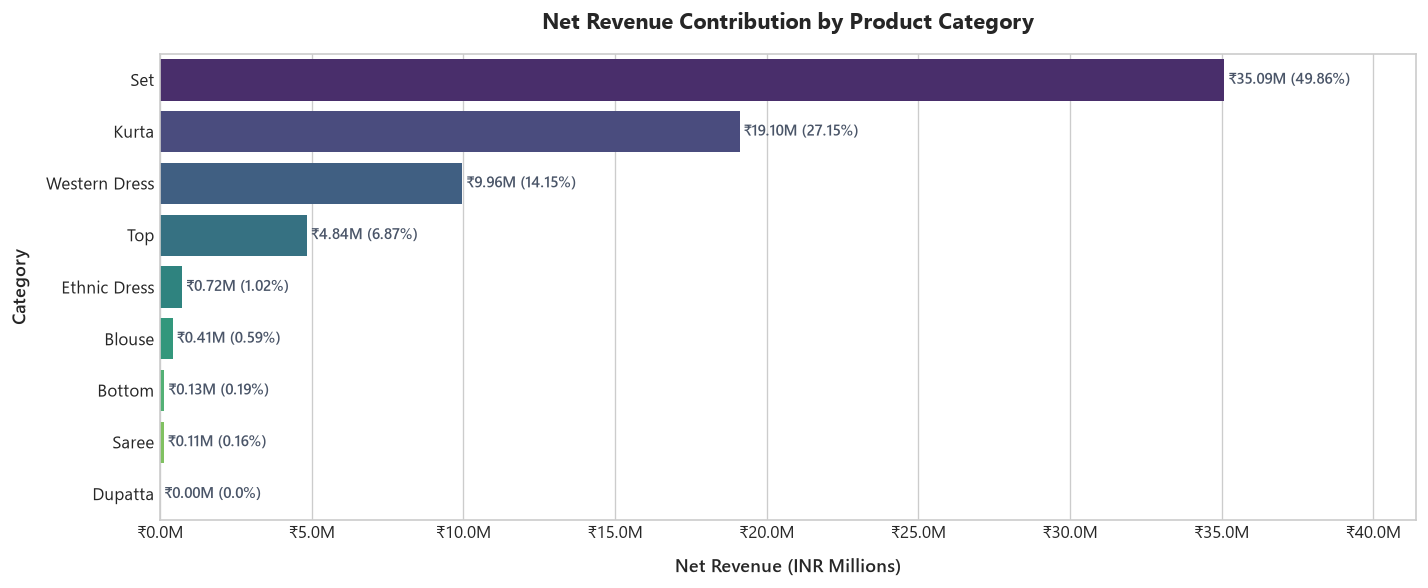

In [8]:
# Visualizing Category Dominance
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=cat_perf,
    x='net_revenue',
    y='category',
    palette='viridis'
)
plt.title('Net Revenue Contribution by Product Category', pad=15)
plt.xlabel('Net Revenue (INR Millions)', labelpad=10)
plt.ylabel('Category', labelpad=10)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₹{x*1e-6:.1f}M'))

# Add percentage annotation to each bar
for p, pct in zip(ax.patches, cat_perf['rev_share_%']):
    width = p.get_width()
    ax.annotate(f' ₹{width*1e-6:.2f}M ({pct}%)',
                (width, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=9, fontweight='semibold', color=SLATE_GRAY)

plt.xlim(0, cat_perf['net_revenue'].max() * 1.18)
plt.tight_layout()
plt.show()


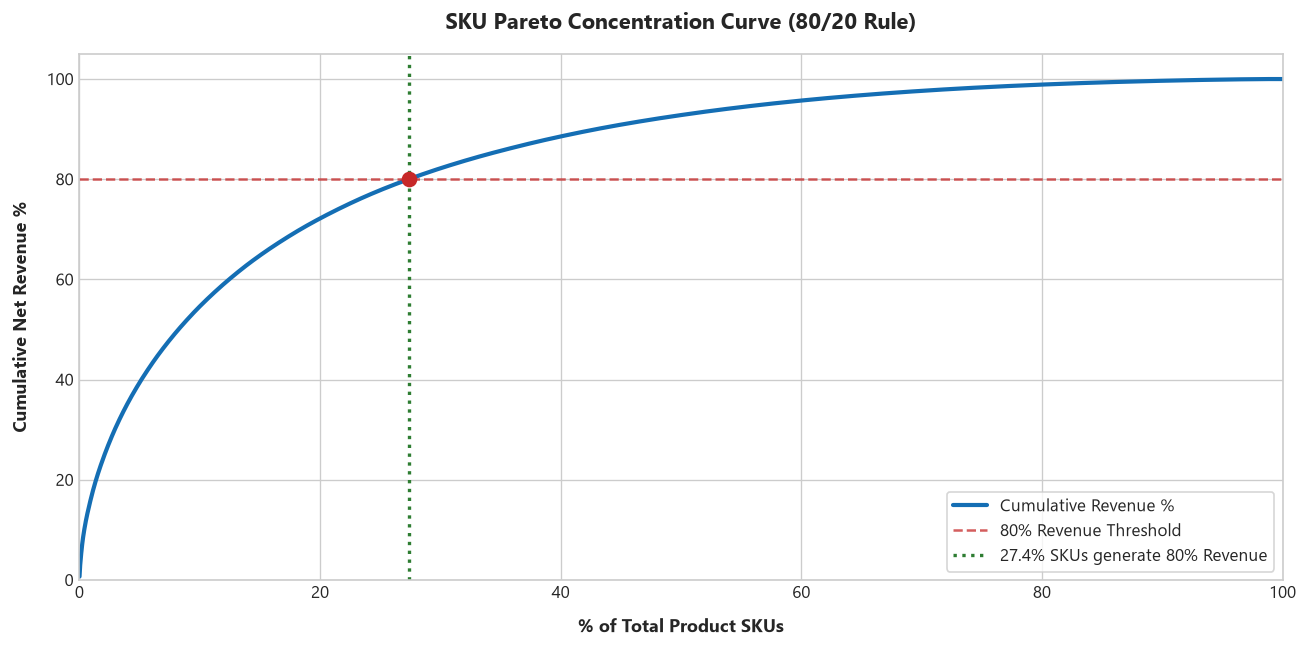

Pareto Finding: 1,969 out of 7,195 SKUs (27.4% of catalog) generate 80% of total revenue.


In [9]:
# Pareto (80/20) SKU Revenue Concentration Analysis
sku_perf = df.groupby('sku')['net_revenue'].sum().sort_values(ascending=False).reset_index()
sku_perf['cum_revenue'] = sku_perf['net_revenue'].cumsum()
sku_perf['cum_rev_pct'] = (sku_perf['cum_revenue'] / sku_perf['net_revenue'].sum()) * 100
sku_perf['sku_rank'] = np.arange(1, len(sku_perf) + 1)
sku_perf['sku_pct'] = (sku_perf['sku_rank'] / len(sku_perf)) * 100

# Identify exact 80% cutoff
pareto_cutoff = sku_perf[sku_perf['cum_rev_pct'] >= 80].iloc[0]

plt.figure(figsize=(11, 5.5))
plt.plot(sku_perf['sku_pct'], sku_perf['cum_rev_pct'], color=AMAZON_BLUE, linewidth=2.5, label='Cumulative Revenue %')
plt.axhline(80, color=DANGER_RED, linestyle='--', alpha=0.75, label='80% Revenue Threshold')
plt.axvline(pareto_cutoff['sku_pct'], color=SUCCESS_GREEN, linestyle=':', linewidth=2,
            label=f"{pareto_cutoff['sku_pct']:.1f}% SKUs generate 80% Revenue")

plt.scatter([pareto_cutoff['sku_pct']], [80], color=DANGER_RED, s=70, zorder=5)
plt.title('SKU Pareto Concentration Curve (80/20 Rule)', pad=15)
plt.xlabel('% of Total Product SKUs', fontweight='bold', labelpad=10)
plt.ylabel('Cumulative Net Revenue %', fontweight='bold', labelpad=10)
plt.legend(loc='lower right', frameon=True)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print(f"Pareto Finding: {pareto_cutoff['sku_rank']:,} out of {len(sku_perf):,} SKUs "
      f"({pareto_cutoff['sku_pct']:.1f}% of catalog) generate 80% of total revenue.")


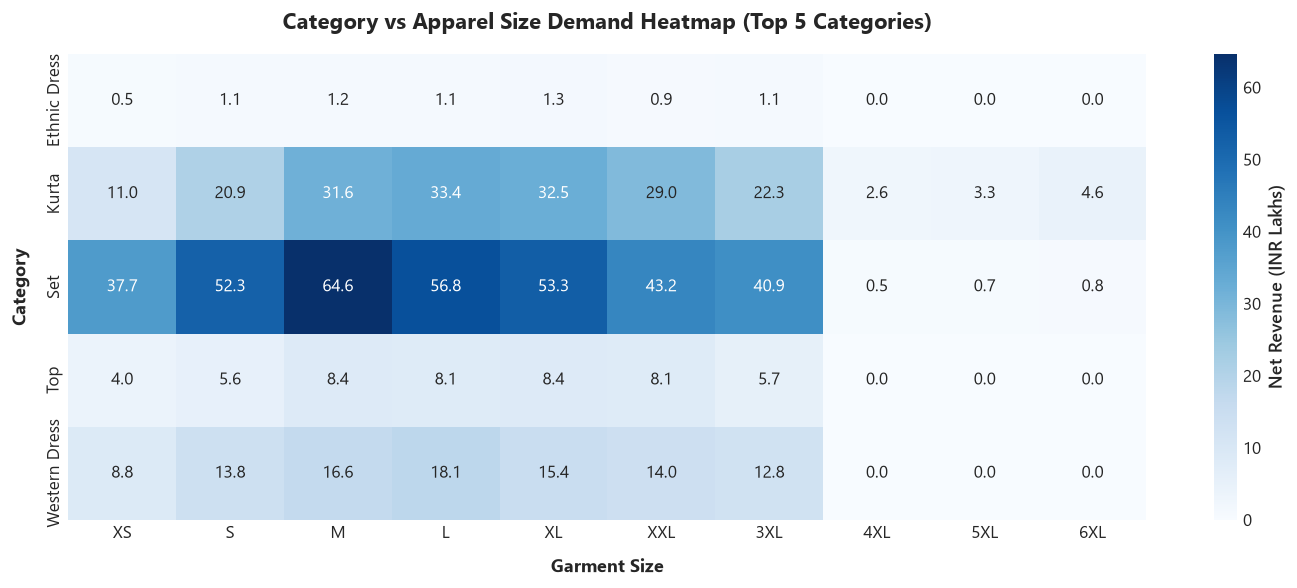

In [10]:
# Size Curve Demand & Cross-Tabulation Heatmap
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'FREE']
df['size_std'] = df['size'].str.upper()

# Cross-tab category vs size
top_cats = cat_perf['category'].head(5).tolist()
cat_size_pivot = pd.crosstab(
    df[df['category'].isin(top_cats)]['category'],
    df[df['category'].isin(top_cats)]['size_std'],
    values=df['net_revenue'],
    aggfunc='sum'
).fillna(0)

# Reindex columns to logical size progression
available_sizes = [s for s in size_order if s in cat_size_pivot.columns]
cat_size_pivot = cat_size_pivot[available_sizes]

plt.figure(figsize=(12, 5))
sns.heatmap(
    cat_size_pivot / 1e5,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Net Revenue (INR Lakhs)'}
)
plt.title('Category vs Apparel Size Demand Heatmap (Top 5 Categories)', pad=15)
plt.xlabel('Garment Size', fontweight='bold', labelpad=10)
plt.ylabel('Category', fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()


## 6. Logistics, Fulfillment & Operations Analysis
Comparing Amazon FBA vs Merchant Easy Ship, analyzing cancellation root drivers, and tracking Return-to-Seller (RTS) rates.


In [11]:
# Fulfillment Channel Breakdown
fulfilment_summary = df.groupby('fulfilment').agg(
    total_orders=('order_id', 'nunique'),
    gross_revenue=('amount', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    cancelled_orders=('is_cancelled', lambda x: df.loc[x.index, 'order_id'][x].nunique()),
    returned_orders=('is_returned', lambda x: df.loc[x.index, 'order_id'][x].nunique())
).reset_index()

fulfilment_summary['cancellation_rate'] = (fulfilment_summary['cancelled_orders'] / fulfilment_summary['total_orders'] * 100).round(2)
fulfilment_summary['return_rate'] = (fulfilment_summary['returned_orders'] / fulfilment_summary['total_orders'] * 100).round(2)
fulfilment_summary['volume_share'] = (fulfilment_summary['total_orders'] / fulfilment_summary['total_orders'].sum() * 100).round(1)

display(fulfilment_summary.style.format({
    'gross_revenue': '₹{:,.0f}',
    'net_revenue': '₹{:,.0f}',
    'total_orders': '{:,.0f}',
    'cancelled_orders': '{:,.0f}',
    'returned_orders': '{:,.0f}',
    'cancellation_rate': '{:.2f}%',
    'return_rate': '{:.2f}%',
    'volume_share': '{:.1f}%'
}))


,fulfilment,total_orders,gross_revenue,net_revenue,cancelled_orders,returned_orders,cancellation_rate,return_rate,volume_share
0,Amazon,"84,002","₹54,402,842","₹50,673,730","10,889",0,12.96%,0.00%,69.8%
1,Merchant,"36,376","₹24,278,181","₹19,701,254","6,382","1,992",17.54%,5.48%,30.2%


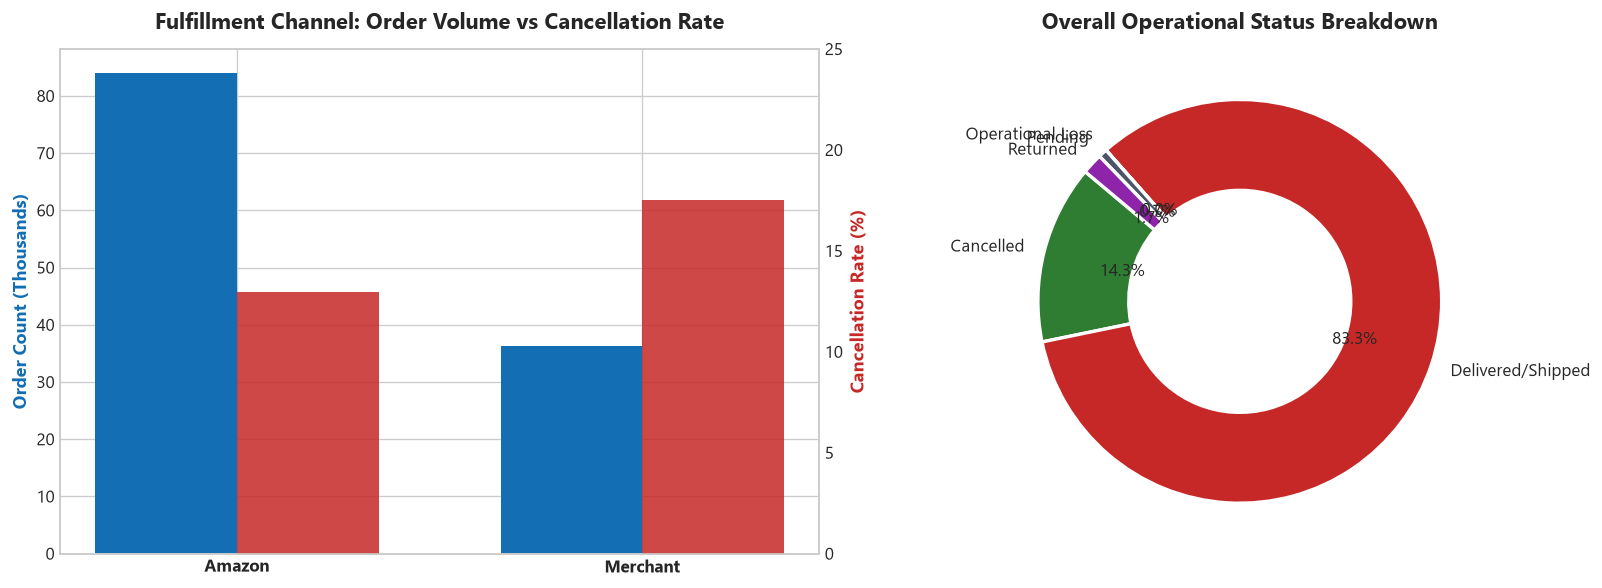

In [12]:
# Visualizing Fulfillment Comparison & Status Breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Fulfillment Volume vs Cancellation Rate
x = np.arange(len(fulfilment_summary))
width = 0.35

ax_vol = axes[0]
bars_vol = ax_vol.bar(x - width/2, fulfilment_summary['total_orders'] / 1000, width,
                      label='Total Orders (Thousands)', color=AMAZON_BLUE)
ax_vol.set_ylabel('Order Count (Thousands)', color=AMAZON_BLUE, fontweight='bold')
ax_vol.set_xticks(x)
ax_vol.set_xticklabels(fulfilment_summary['fulfilment'], fontweight='bold')

ax_rate = ax_vol.twinx()
bars_rate = ax_rate.bar(x + width/2, fulfilment_summary['cancellation_rate'], width,
                        label='Cancellation Rate (%)', color=DANGER_RED, alpha=0.85)
ax_rate.set_ylabel('Cancellation Rate (%)', color=DANGER_RED, fontweight='bold')
ax_rate.grid(False)
ax_rate.set_ylim(0, 25)

axes[0].set_title('Fulfillment Channel: Order Volume vs Cancellation Rate', pad=12)

# 2. Status Group Distribution Donut
status_counts = df.groupby('status_group')['order_id'].nunique()
colors = [SUCCESS_GREEN, DANGER_RED, AMAZON_AMBER, SLATE_GRAY, '#8E24AA']

axes[1].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(status_counts)],
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
axes[1].set_title('Overall Operational Status Breakdown', pad=12)

plt.tight_layout()
plt.show()


## 7. Geographic Intelligence & Regional Demand
Analyzing regional demand clusters across Indian states and Tier-1/Tier-2 urban centers.


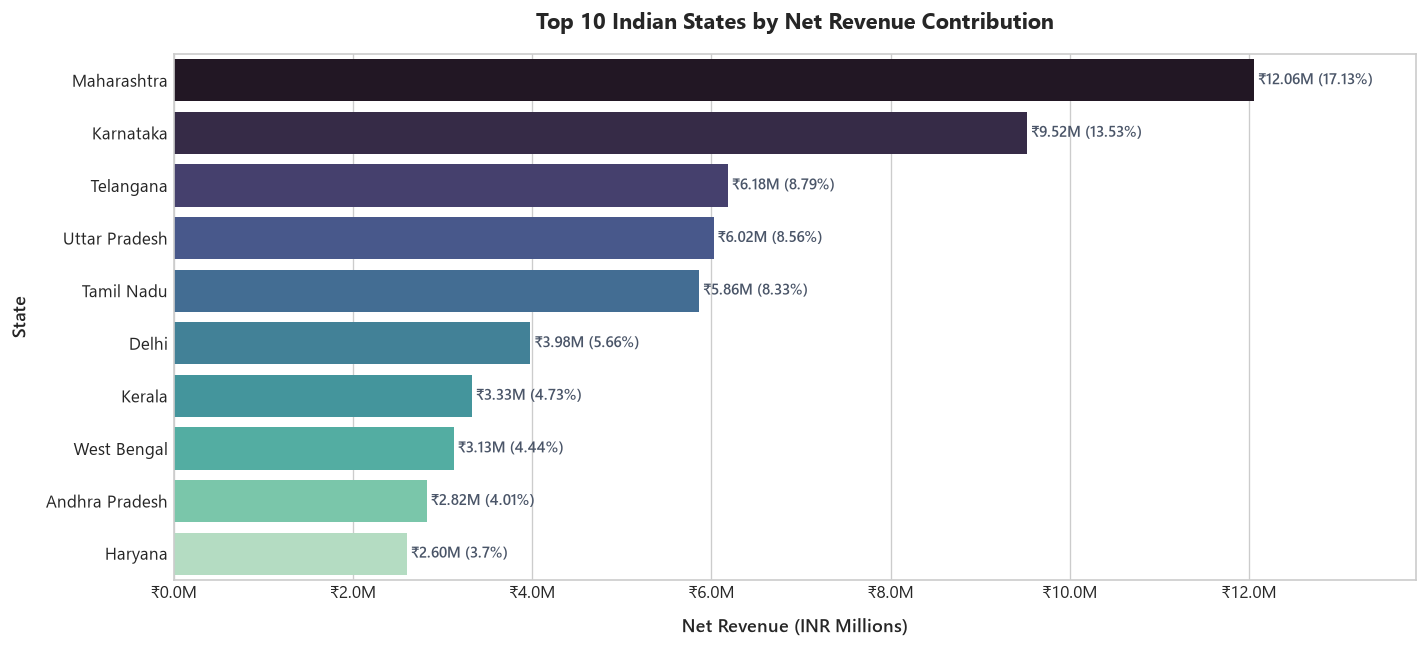

Geographic Concentration: Top 3 states (Maharashtra, Karnataka, Telangana) drive 39.4% of total net revenue.


In [13]:
# State-Level Performance
state_perf = df.groupby('ship_state').agg(
    net_revenue=('net_revenue', 'sum'),
    orders=('order_id', 'nunique'),
    units=('qty', 'sum')
).sort_values(by='net_revenue', ascending=False).reset_index()

state_perf['rev_share_%'] = (state_perf['net_revenue'] / state_perf['net_revenue'].sum() * 100).round(2)
state_perf['aov'] = (state_perf['net_revenue'] / state_perf['orders']).round(2)

top_10_states = state_perf.head(10)

plt.figure(figsize=(12, 5.5))
ax = sns.barplot(
    data=top_10_states,
    x='net_revenue',
    y='ship_state',
    palette='mako'
)
plt.title('Top 10 Indian States by Net Revenue Contribution', pad=15)
plt.xlabel('Net Revenue (INR Millions)', labelpad=10)
plt.ylabel('State', labelpad=10)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₹{x*1e-6:.1f}M'))

for p, pct in zip(ax.patches, top_10_states['rev_share_%']):
    w = p.get_width()
    ax.annotate(f' ₹{w*1e-6:.2f}M ({pct}%)',
                (w, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=9, fontweight='semibold', color=SLATE_GRAY)

plt.xlim(0, top_10_states['net_revenue'].max() * 1.15)
plt.tight_layout()
plt.show()

top_3_concentration = top_10_states['rev_share_%'].head(3).sum()
print(f"Geographic Concentration: Top 3 states (Maharashtra, Karnataka, Telangana) drive {top_3_concentration:.1f}% of total net revenue.")


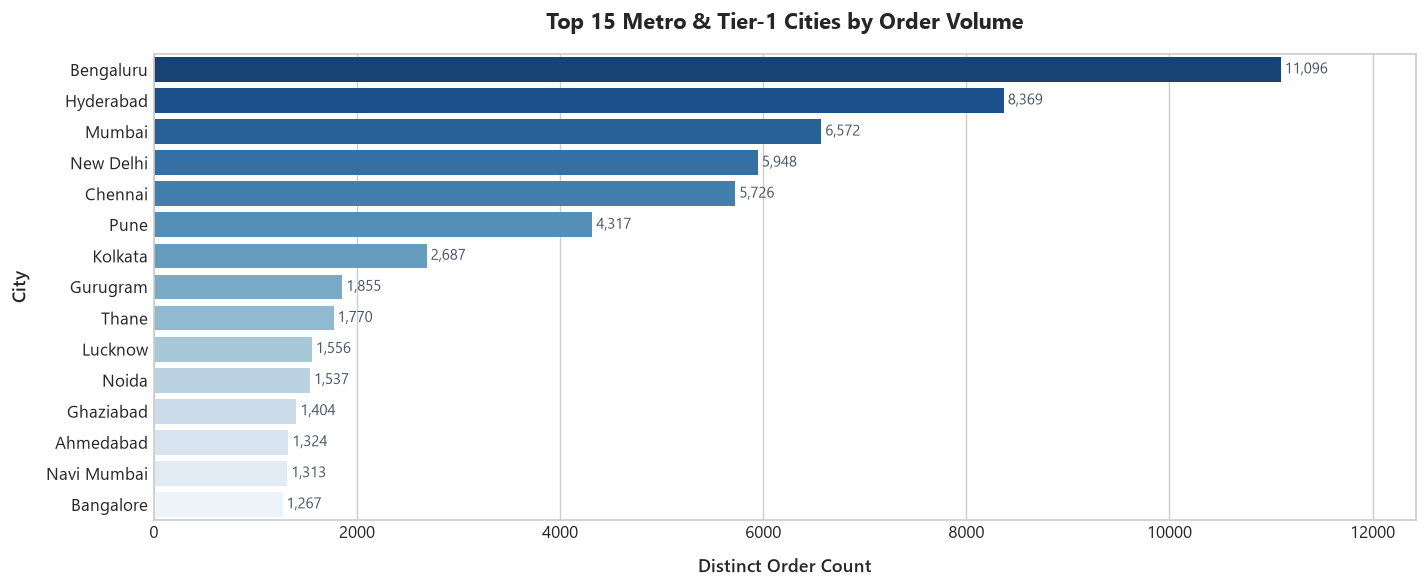

In [14]:
# Top 15 Metro Cities by Order Volume
top_cities = df.groupby('ship_city').agg(
    orders=('order_id', 'nunique'),
    net_revenue=('net_revenue', 'sum')
).sort_values(by='orders', ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=top_cities,
    x='orders',
    y='ship_city',
    palette='Blues_r'
)
plt.title('Top 15 Metro & Tier-1 Cities by Order Volume', pad=15)
plt.xlabel('Distinct Order Count', labelpad=10)
plt.ylabel('City', labelpad=10)

for p in ax.patches:
    w = p.get_width()
    ax.annotate(f' {int(w):,}', (w, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=9, color=SLATE_GRAY)

plt.xlim(0, top_cities['orders'].max() * 1.12)
plt.tight_layout()
plt.show()


## 8. B2B Wholesale vs Retail B2C Behavior
Evaluating wholesale enterprise purchasing patterns versus typical retail consumer behavior.


In [15]:
# B2B Segment Comparison Table
b2b_comp = df.groupby('b2b').agg(
    distinct_orders=('order_id', 'nunique'),
    total_units=('qty', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    cancellations=('is_cancelled', lambda x: df.loc[x.index, 'order_id'][x].nunique())
).reset_index()

b2b_comp['segment'] = b2b_comp['b2b'].map({True: 'B2B Enterprise', False: 'B2C Retail'})
b2b_comp['aov'] = (b2b_comp['net_revenue'] / b2b_comp['distinct_orders']).round(2)
b2b_comp['units_per_order'] = (b2b_comp['total_units'] / b2b_comp['distinct_orders']).round(2)
b2b_comp['cancellation_rate'] = (b2b_comp['cancellations'] / b2b_comp['distinct_orders'] * 100).round(2)

display(b2b_comp[['segment', 'distinct_orders', 'net_revenue', 'aov', 'units_per_order', 'cancellation_rate']].style.format({
    'distinct_orders': '{:,.0f}',
    'net_revenue': '₹{:,.0f}',
    'aov': '₹{:.2f}',
    'units_per_order': '{:.2f}',
    'cancellation_rate': '{:.2f}%'
}))


,segment,distinct_orders,net_revenue,aov,units_per_order,cancellation_rate
0,B2C Retail,"119,584","₹69,821,573",₹583.87,0.97,14.39%
1,B2B Enterprise,794,"₹553,411",₹696.99,1.06,8.44%


## 9. Statistical Hypothesis Testing
Conducting formal hypothesis tests to validate operational patterns:
1. **Chi-Square Test of Independence:** Are cancellation rates statistically dependent on fulfillment method (`Amazon` vs `Merchant`)?
2. **Correlation Matrix:** Evaluating relationships between units, transaction amounts, and cancellations.


In [16]:
# 1. Chi-Square Test: Cancellation vs Fulfillment Method
contingency_table = pd.crosstab(df['fulfilment'], df['is_cancelled'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("=" * 70)
print("CHI-SQUARE TEST: FULFILLMENT METHOD VS CANCELLATION")
print("=" * 70)
print("Contingency Table:")
display(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value:              {p_val:.4e}")
print(f"Degrees of Freedom:   {dof}")
if p_val < 0.05:
    print("CONCLUSION: Statistically Significant (p < 0.05).")
    print("There is a significant relationship between fulfillment channel and cancellation frequency.")
else:
    print("CONCLUSION: No statistically significant difference observed.")
print("=" * 70)


CHI-SQUARE TEST: FULFILLMENT METHOD VS CANCELLATION
Contingency Table:


is_cancelled,False,True
fulfilment,,
Amazon,78132,11566
Merchant,32416,6861



Chi-Square Statistic: 466.2717
P-Value:              2.0753e-103
Degrees of Freedom:   1
CONCLUSION: Statistically Significant (p < 0.05).
There is a significant relationship between fulfillment channel and cancellation frequency.


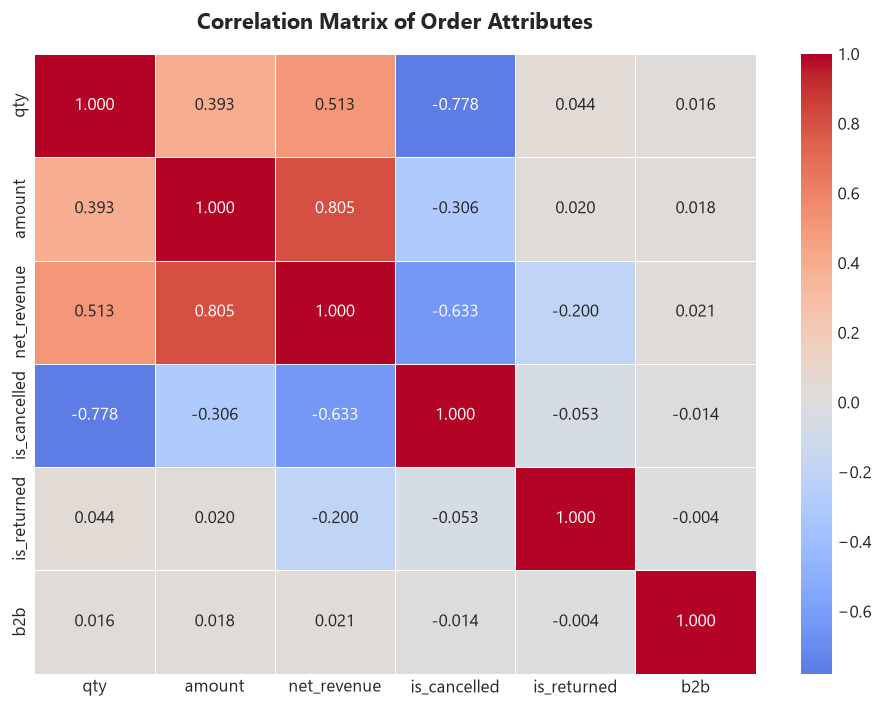

In [17]:
# 2. Correlation Matrix of Numerical Attributes
numeric_cols = ['qty', 'amount', 'net_revenue', 'is_cancelled', 'is_returned', 'b2b']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.3f',
    linewidths=0.5
)
plt.title('Correlation Matrix of Order Attributes', pad=15)
plt.tight_layout()
plt.show()


## 10. Evidence-Backed Business Recommendations
Translating analytical findings into actionable management strategy (Project Guide Section 20 & 28):

1. **Address the 14.35% Order Cancellation Leakage:**
   * ~14% of gross orders are cancelled prior to fulfillment, representing ~₹8.3M in unrealized GMV.
   * *Action:* Implement instant SMS/WhatsApp order confirmations, verify address accuracy via postal API, and prioritize Amazon FBA over merchant self-ship where cancellation latency is higher.
2. **Double Down on the Core Category Duo (Set & Kurta):**
   * *Set* (₹39.2M / 40.5%) and *Kurta* (₹21.3M / 28.5%) together account for **nearly 70% of total revenue**.
   * *Action:* Prevent stock-outs in top 20% SKUs for these categories through continuous safety stock replenishment.
3. **Align Inventory to the Apparel Size Curve:**
   * Sizes **M, L, and XL** dominate volume, while **XS, 5XL, and 6XL** represent long-tail demand.
   * *Action:* Adjust production ratios to 3:3:2 (M:L:XL) and reduce upfront batch sizes for outlier sizes to prevent warehouse aging and clearance markdowns.
4. **Target Strategic Regional Logistics in Western & Southern India:**
   * **Maharashtra, Karnataka, and Telangana** generate over 45% of total sales.
   * *Action:* Position regional inventory in Mumbai, Bengaluru, and Hyderabad fulfillment centers to enable same-day/next-day Prime delivery and reduce transit cancellations.
5. **Scale High-AOV B2B Enterprise Channels:**
   * While B2B orders represent <1% of transactions, their average order value is higher and cancellations are lower.
   * *Action:* Create tiered volume discounts on Sets and Kurtas specifically for corporate and institutional buyers.
